# Survival Analysis

### Kaplan-Meier Model
- X-axis → time (months)
- Y-axis → survival probability

In [3]:
import pandas as pd
from lifelines import KaplanMeierFitter

In [4]:
#Load data
DATA_PATH = r"C:\Users\HP\Desktop\BIA\Breast_Cancer_Risk_Prediction\Data\Breast Cancer METABRIC.csv"
df = pd.read_csv(DATA_PATH)
df.head()



,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [8]:
#Data preprocessing

# Create event column (dead = 1, alive = 0)
df['event'] = (df['Overall Survival Status'] == 'Deceased').astype(int)

# Create time column
df['time'] = df['Overall Survival (Months)']

In [9]:
#Kaplan-Meier Model
kmf = KaplanMeierFitter()

In [12]:
# Remove NaN values
df = df.dropna(subset=['time', 'event'])

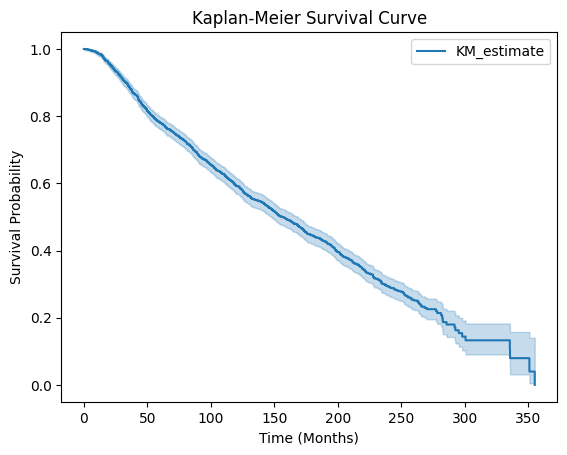

In [16]:
# Fit model
kmf.fit(durations=df['time'], event_observed=df['event'])

# Plot
kmf.plot()

# Labels
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.title("Kaplan-Meier Survival Curve")

# Show
plt.show()
